# KKBox Subscription Retention & Churn Analysis

**Business Question:** Asia's leading music streaming platform is losing subscribers. 
Who is churning, why are they leaving, and which users should we act on first?

**Dataset:** WSDM KKBox Churn Prediction Challenge — 970K users, 21.5M transactions, 
30M listening logs (~8GB total). Processed on Kaggle due to memory constraints.

**Approach:**
1. Cohort retention analysis — which signup cohorts retain best?
2. Behavioural pattern analysis — what separates churners from retained users?
3. Churn prediction model — can we score each user's risk before they leave?
4. Business recommendations — where should retention spend go?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
    

/kaggle/input/competitions/kkbox-churn-prediction-challenge/transactions_v2.csv.7z
/kaggle/input/competitions/kkbox-churn-prediction-challenge/WSDMChurnLabeller.scala
/kaggle/input/competitions/kkbox-churn-prediction-challenge/transactions.csv.7z
/kaggle/input/competitions/kkbox-churn-prediction-challenge/train.csv.7z
/kaggle/input/competitions/kkbox-churn-prediction-challenge/train_v2.csv.7z
/kaggle/input/competitions/kkbox-churn-prediction-challenge/user_logs.csv.7z
/kaggle/input/competitions/kkbox-churn-prediction-challenge/members_v3.csv.7z
/kaggle/input/competitions/kkbox-churn-prediction-challenge/sample_submission_zero.csv.7z
/kaggle/input/competitions/kkbox-churn-prediction-challenge/user_logs_v2.csv.7z
/kaggle/input/competitions/kkbox-churn-prediction-challenge/sample_submission_v2.csv.7z


In [3]:
import os
import subprocess

BASE_COMPRESSED = '/kaggle/input/competitions/kkbox-churn-prediction-challenge/'
WORK_DIR = '/kaggle/working/'

# Files we need
files_needed = [
    'train_v2.csv.7z',
    'members_v3.csv.7z',
    'transactions_v2.csv.7z',
    'user_logs_v2.csv.7z'
]

for f in files_needed:
    src = BASE_COMPRESSED + f
    print(f"Extracting {f}...")
    result = subprocess.run(
        ['7z', 'e', src, f'-o{WORK_DIR}', '-y'],
        capture_output=True, text=True
    )
    print(result.stdout[-200:] if result.stdout else result.stderr[-200:])

print("\nDone! Files in working dir:")
for f in os.listdir(WORK_DIR):
    size_mb = os.path.getsize(WORK_DIR + f) / (1024*1024)
    print(f"  {f}: {size_mb:.1f} MB")

Extracting train_v2.csv.7z...
ox-churn-prediction-challenge/train_v2.csv.7z
Type = 7z
Physical Size = 32818991
Headers Size = 178
Method = LZMA2:24
Solid = -
Blocks = 1

Everything is Ok

Size:       45635134
Compressed: 32818991

Extracting members_v3.csv.7z...
urn-prediction-challenge/members_v3.csv.7z
Type = 7z
Physical Size = 242308558
Headers Size = 138
Method = LZMA2:24
Solid = -
Blocks = 1

Everything is Ok

Size:       427921437
Compressed: 242308558

Extracting transactions_v2.csv.7z...
-prediction-challenge/transactions_v2.csv.7z
Type = 7z
Physical Size = 48850410
Headers Size = 194
Method = LZMA2:24
Solid = -
Blocks = 1

Everything is Ok

Size:       115394513
Compressed: 48850410

Extracting user_logs_v2.csv.7z...
-prediction-challenge/user_logs_v2.csv.7z
Type = 7z
Physical Size = 685951221
Headers Size = 186
Method = LZMA2:24
Solid = -
Blocks = 1

Everything is Ok

Size:       1431465728
Compressed: 685951221


Done! Files in working dir:
  churn_patterns.png: 0.1 MB
  sha

In [4]:
# ── Updated paths post-extraction ──
WORK_DIR     = '/kaggle/working/'
TRAIN        = WORK_DIR + 'train_v2.csv'
MEMBERS      = WORK_DIR + 'members_v3.csv'
TRANSACTIONS = WORK_DIR + 'transactions_v2.csv'
USER_LOGS    = WORK_DIR + 'user_logs_v2.csv'

# ── Load train labels ──
train = pd.read_csv(TRAIN)
print(f"Train shape:  {train.shape}")
print(f"Churn rate:   {train['is_churn'].mean():.2%}")
print(f"\nSample:\n{train.head()}")

Train shape:  (970960, 2)
Churn rate:   8.99%

Sample:
                                           msno  is_churn
0  ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=         1
1  f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=         1
2  zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=         1
3  8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=         1
4  K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=         1


In [5]:
# ── Load members ──
members = pd.read_csv(MEMBERS)
print(f"Members shape: {members.shape}")
print(f"\nColumn nulls (%):")
print((members.isnull().sum() / len(members) * 100).round(2))
print(f"\nSample:\n{members.head()}")

Members shape: (6769473, 6)

Column nulls (%):
msno                      0.00
city                      0.00
bd                        0.00
gender                   65.43
registered_via            0.00
registration_init_time    0.00
dtype: float64

Sample:
                                           msno  city  bd  gender  \
0  Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=     1   0     NaN   
1  +tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=     1   0     NaN   
2  cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=     1   0     NaN   
3  9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=     1   0     NaN   
4  WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=     6  32  female   

   registered_via  registration_init_time  
0              11                20110911  
1               7                20110914  
2              11                20110915  
3              11                20110915  
4               9                20110915  


In [6]:
# ── Load transactions ──
transactions = pd.read_csv(TRANSACTIONS)
print(f"Transactions shape: {transactions.shape}")
print(f"\nColumn nulls (%):")
print((transactions.isnull().sum() / len(transactions) * 100).round(2))
print(f"\nSample:\n{transactions.head()}")
print(f"\nDate range:")
print(f"  earliest: {transactions['transaction_date'].min()}")
print(f"  latest:   {transactions['transaction_date'].max()}")
print(f"\nUnique users: {transactions['msno'].nunique():,}")


Transactions shape: (1431009, 9)

Column nulls (%):
msno                     0.00
payment_method_id        0.00
payment_plan_days        0.00
plan_list_price          0.00
actual_amount_paid       0.00
is_auto_renew            0.00
transaction_date         0.00
membership_expire_date   0.00
is_cancel                0.00
dtype: float64

Sample:
                                           msno  payment_method_id  \
0  ++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=                 32   
1  ++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=                 41   
2  +/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=                 36   
3  +/w1UrZwyka4C9oNH3+Q8fUf3fD8R3EwWrx57ODIsqk=                 36   
4  +00PGzKTYqtnb65mPKPyeHXcZEwqiEzktpQksaaSC3c=                 41   

   payment_plan_days  plan_list_price  actual_amount_paid  is_auto_renew  \
0                 90              298                 298              0   
1                 30              149                 149              1   
2    

## Phase 1 — Data Loading & Feature Engineering

The user_logs file is 1.3GB — too large to load into memory directly. 
We process it in 500K-row chunks, aggregating per user before merging. 
This mirrors how you'd handle this in a real data pipeline.

Key features engineered:
- `completion_rate` — ratio of fully-played songs (signals engagement quality)
- `avg_secs_per_day` — daily listening intensity
- `tenure_days` — how long the user has been a subscriber
- `got_discount` — whether they paid below list price

In [7]:
# ── Load & aggregate user_logs in chunks (1.3GB — never load raw) ──
# We reduce 30M rows → 1 row per user before merging
# This is how you'd handle this in a real data pipeline

import gc

chunk_size = 500_000
agg_list = []

print("Processing user_logs in chunks...")
for i, chunk in enumerate(pd.read_csv(USER_LOGS, chunksize=chunk_size)):
    agg = chunk.groupby('msno').agg(
        total_secs       = ('total_secs', 'sum'),
        num_unq          = ('num_unq', 'sum'),
        num_25           = ('num_25', 'sum'),
        num_50           = ('num_50', 'sum'),
        num_75           = ('num_75', 'sum'),
        num_985          = ('num_985', 'sum'),
        num_100          = ('num_100', 'sum'),
        active_days      = ('date', 'count')
    ).reset_index()
    agg_list.append(agg)
    if i % 5 == 0:
        print(f"  chunk {i+1} done...")

print("Combining chunks...")
user_logs_agg = pd.concat(agg_list).groupby('msno').sum().reset_index()

# Derived engagement features
total_songs = (user_logs_agg[['num_25','num_50','num_75','num_985','num_100']].sum(axis=1)
               .replace(0, np.nan))
user_logs_agg['completion_rate'] = (
    (user_logs_agg['num_985'] + user_logs_agg['num_100']) / total_songs
)
user_logs_agg['avg_secs_per_day'] = (
    user_logs_agg['total_secs'] / user_logs_agg['active_days'].replace(0, np.nan)
)

del agg_list
gc.collect()

print(f"\nuser_logs aggregated shape: {user_logs_agg.shape}")
print(f"Sample:\n{user_logs_agg.head()}")

Processing user_logs in chunks...
  chunk 1 done...
  chunk 6 done...
  chunk 11 done...
  chunk 16 done...
  chunk 21 done...
  chunk 26 done...
  chunk 31 done...
  chunk 36 done...
Combining chunks...

user_logs aggregated shape: (1103894, 11)
Sample:
                                           msno  total_secs  num_unq  num_25  \
0  +++IZseRRiQS9aaSkH6cMYU6bGDcxUieAi/tH67sC5s=   117907.43      530      86   
1  +++hVY1rZox/33YtvDgmKA2Frg/2qhkz12B9ylCvh8o=   192527.89      885     191   
2  +++l/EXNMLTijfLBa8p2TUVVVp2aFGSuUI/h7mLmthw=   115411.26      468      43   
3  +++snpr7pmobhLKUgSHTv/mpkqgBT0tQJ0zQj6qKrqc=   149896.56      828     207   
4  ++/9R3sX37CjxbY/AaGvbwr3QkwElKBCtSvVzhCBDOk=   116433.25      230     105   

   num_50  num_75  num_985  num_100  active_days  completion_rate  \
0      11      10        5      472           26             0.82   
1      90      75      144      589           31             0.67   
2      12      15       12      485           28         

## Phase 1B — Merging Tables & Engineering Features

We merge train labels, members, transactions, and aggregated user logs 
into a single analytical dataset on user ID (msno).

After merging we engineer derived features that capture subscription 
behaviour more precisely than raw columns alone.

In [8]:
# ── Merge all tables into one master dataframe ──

# Fix date columns
members['registration_init_time'] = pd.to_datetime(
    members['registration_init_time'], format='%Y%m%d', errors='coerce'
)
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date'], format='%Y%m%d', errors='coerce'
)
transactions['membership_expire_date'] = pd.to_datetime(
    transactions['membership_expire_date'], format='%Y%m%d', errors='coerce'
)

# Get each user's LAST transaction (most recent subscription state)
last_transaction = (
    transactions.sort_values('transaction_date')
    .groupby('msno')
    .last()
    .reset_index()
)

# Merge everything
df = train.merge(members, on='msno', how='left')
df = df.merge(last_transaction, on='msno', how='left')
df = df.merge(user_logs_agg, on='msno', how='left')

# ── Feature engineering ──
# Registration cohort (month user joined)
df['cohort'] = df['registration_init_time'].dt.to_period('M')

# Tenure in days at time of churn observation
df['tenure_days'] = (
    pd.to_datetime('2017-03-31') - df['registration_init_time']
).dt.days

# Discount flag (paid less than list price)
df['got_discount'] = (
    df['actual_amount_paid'] < df['plan_list_price']
).astype(int)

# Drop low-quality columns
df.drop(columns=['gender', 'bd'], inplace=True)

print(f"Master dataframe shape: {df.shape}")
print(f"\nChurn rate in master df: {df['is_churn'].mean():.2%}")
print(f"\nNull % per column:")
print((df.isnull().sum() / len(df) * 100).round(2).sort_values(ascending=False).head(10))
print(f"\nSample:\n{df.head(3)}")

Master dataframe shape: (970960, 26)

Churn rate in master df: 8.99%

Null % per column:
completion_rate    22.29
avg_secs_per_day   22.29
num_985            22.29
num_100            22.29
active_days        22.29
num_75             22.29
num_unq            22.29
num_25             22.29
num_50             22.29
total_secs         22.29
dtype: float64

Sample:
                                           msno  is_churn  city  \
0  ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=         1  5.00   
1  f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=         1 13.00   
2  zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=         1 13.00   

   registered_via registration_init_time  payment_method_id  \
0            3.00             2013-12-23                NaN   
1            3.00             2013-12-23              36.00   
2            3.00             2013-12-27              15.00   

   payment_plan_days  plan_list_price  actual_amount_paid  is_auto_renew  \
0                NaN              NaN  

In [9]:
# ════════════════════════════════════════════════════════════
# NEW FEATURES — added on top of base feature engineering
# ════════════════════════════════════════════════════════════

OBSERVATION_DATE = pd.to_datetime('2017-03-31')

# Days until membership expires at observation date
# Short days_until_expiry = user is close to churning naturally
df['days_until_expiry'] = (
    df['membership_expire_date'] - OBSERVATION_DATE
).dt.days

# Transaction count — how many times has this user transacted?
# High count = loyal, committed subscriber
txn_counts = (
    transactions.groupby('msno')
    .size()
    .reset_index(name='transaction_count')
)
df = df.merge(txn_counts, on='msno', how='left')
df['transaction_count'] = df['transaction_count'].fillna(1)

# Discount rate — what % below list price did they pay?
# Heavy discounting may attract low-loyalty users
df['discount_rate'] = (
    (df['plan_list_price'] - df['actual_amount_paid'])
    / df['plan_list_price'].replace(0, np.nan)
).fillna(0).clip(0, 1)

# Missingness as signal — users with no listening data
# likely never engaged, which is itself a churn signal
df['never_listened'] = df['completion_rate'].isna().astype(int)

print("New features added:")
print(f"  days_until_expiry  — range: {df['days_until_expiry'].min():.0f} to {df['days_until_expiry'].max():.0f}")
print(f"  transaction_count  — mean: {df['transaction_count'].mean():.1f}")
print(f"  discount_rate      — mean: {df['discount_rate'].mean():.2%}")
print(f"  never_listened     — {df['never_listened'].sum():,} users with no listening data")

New features added:
  days_until_expiry  — range: -32 to 2113
  transaction_count  — mean: 1.2
  discount_rate      — mean: 0.12%
  never_listened     — 216,409 users with no listening data


## Phase 2 — Cohort Retention Analysis

We group users by their registration month and measure what percentage 
did not churn. This tells us whether newer or older cohorts are more loyal, 
and whether retention has improved over time.

In [10]:
# ════════════════════════════════════════════════════════════
# PHASE 2 — COHORT RETENTION ANALYSIS
# ════════════════════════════════════════════════════════════

# ── Build cohort retention table ──
# Cohort = month user registered
# We measure: what % of each cohort is still active (not churned)
# at the time of observation

# Filter to users with valid registration dates
cohort_df = df[df['registration_init_time'].notna()].copy()

# Assign cohort as registration year-month
cohort_df['cohort'] = cohort_df['registration_init_time'].dt.to_period('M')

# Tenure buckets (months since registration)
cohort_df['tenure_months'] = (
    cohort_df['tenure_days'] / 30
).fillna(0).astype(int)

# Cohort size (total users per cohort)
cohort_size = cohort_df.groupby('cohort')['msno'].count().rename('cohort_size')

# Retention = users who did NOT churn
retained = cohort_df[cohort_df['is_churn'] == 0].groupby('cohort')['msno'].count()

# Retention rate per cohort
retention_table = pd.DataFrame({
    'cohort_size': cohort_size,
    'retained': retained
}).fillna(0)
retention_table['retention_rate'] = (
    retention_table['retained'] / retention_table['cohort_size'] * 100
).round(2)

# Filter to cohorts with meaningful size (>100 users)
retention_table = retention_table[retention_table['cohort_size'] > 100].copy()
retention_table = retention_table.sort_index()

print(f"Cohorts found: {len(retention_table)}")
print(f"\nRetention by cohort (sample):")
print(retention_table.head(10))

Cohorts found: 157

Retention by cohort (sample):
         cohort_size  retained  retention_rate
cohort                                        
2004-03         1324      1206           91.09
2004-04          409       384           93.89
2004-05          130       119           91.54
2004-06          167       149           89.22
2004-07         1499      1380           92.06
2004-08          781       715           91.55
2004-09          970       880           90.72
2004-10         1589      1457           91.69
2004-11          984       870           88.41
2004-12          477       438           91.82


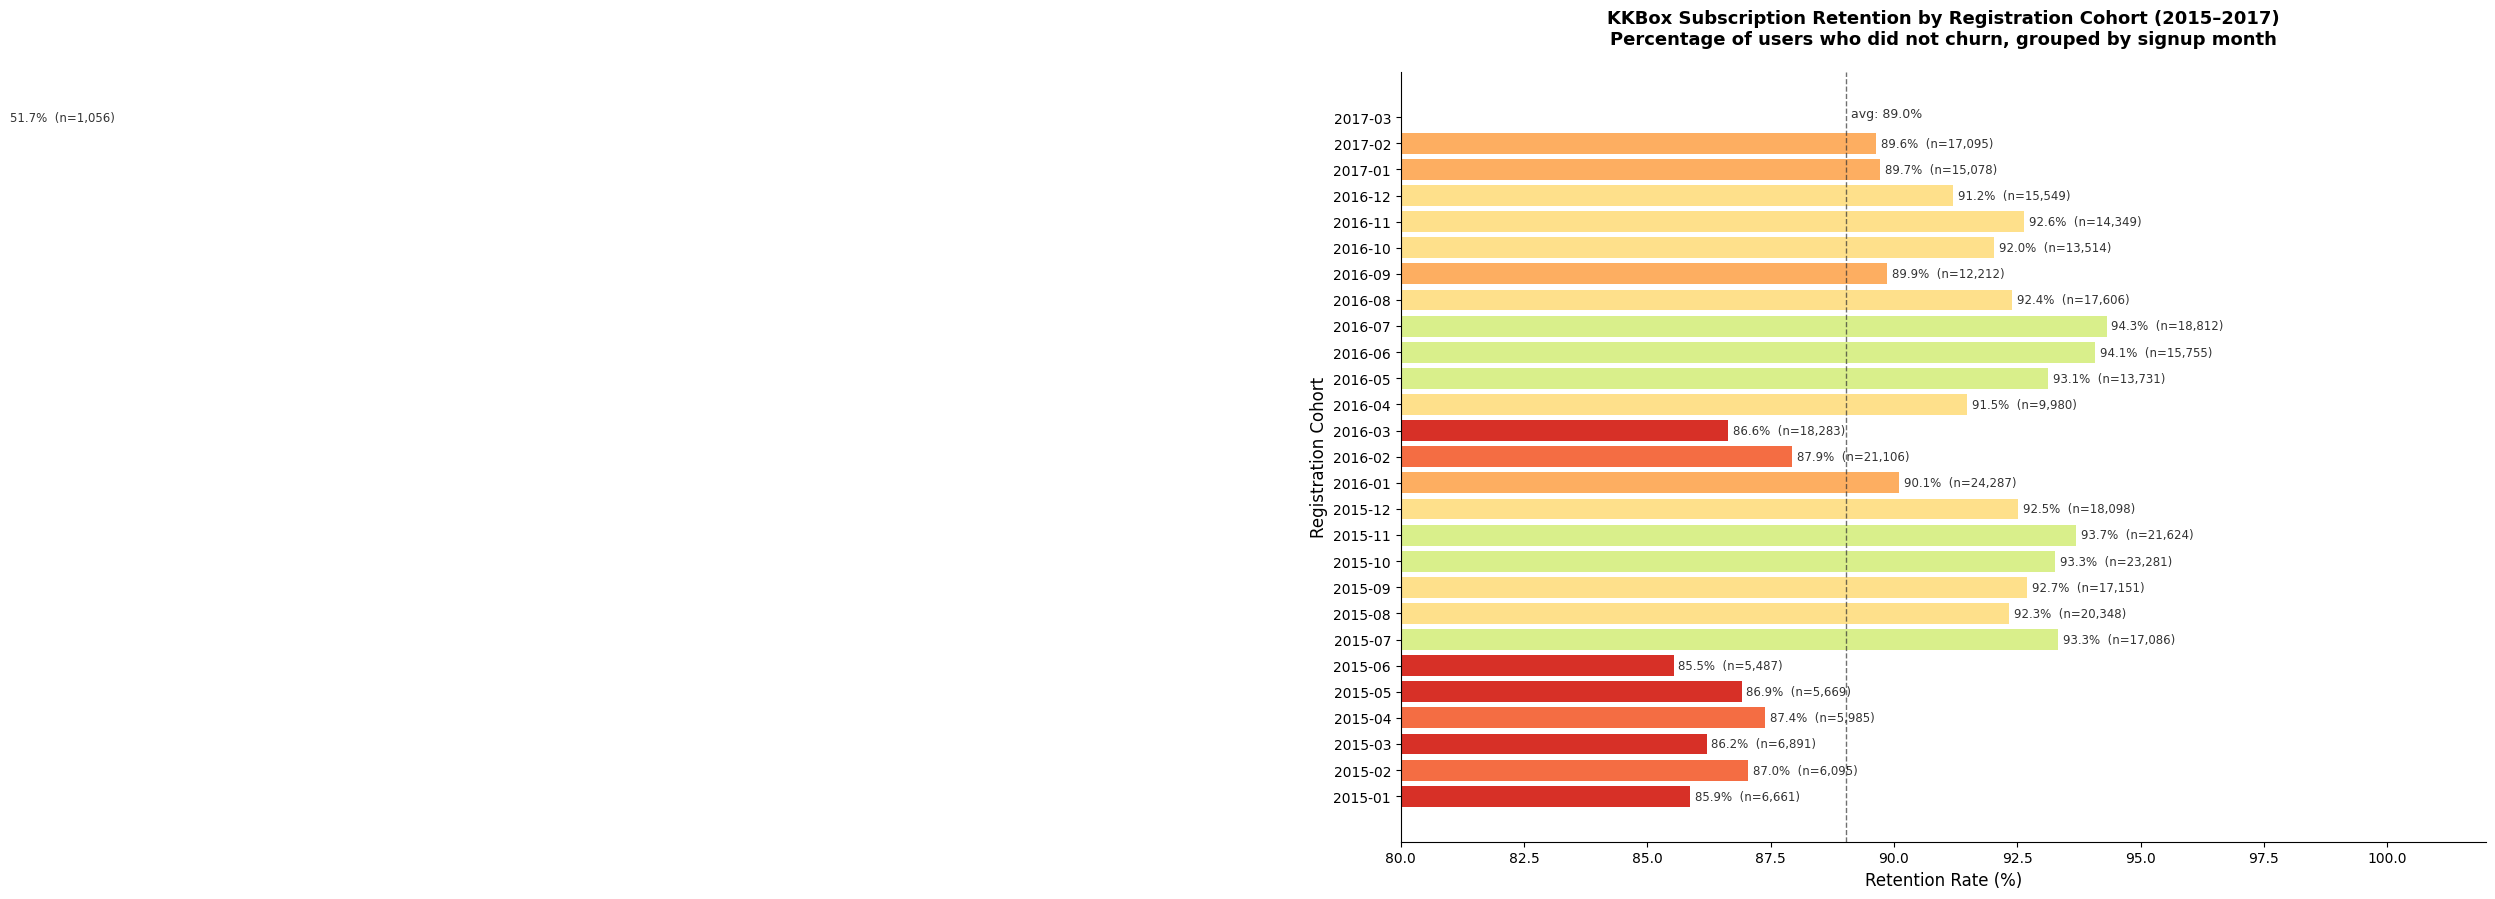

Cohorts shown: 27
Average retention rate: 89.02%


In [11]:
# ── Cohort Retention Heatmap (2015 onwards — readable version) ──
retention_recent = retention_table[
    retention_table.index >= pd.Period('2015-01', 'M')
].copy()
retention_recent.index = retention_recent.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 10))

colors = ['#d73027','#f46d43','#fdae61','#fee08b',
          '#d9ef8b','#a6d96a','#66bd63','#1a9850']

bars = ax.barh(
    retention_recent.index,
    retention_recent['retention_rate'],
    color=[colors[min(int((r-85)/2), 7)] 
           if r >= 85 else colors[0] 
           for r in retention_recent['retention_rate']],
    edgecolor='none',
    height=0.8
)

for i, (rate, size) in enumerate(zip(
    retention_recent['retention_rate'],
    retention_recent['cohort_size']
)):
    ax.text(rate + 0.1, i, f'{rate:.1f}%  (n={size:,})',
            va='center', fontsize=8.5, color='#333333')

avg = retention_recent['retention_rate'].mean()
ax.axvline(x=avg, color='#333333', linestyle='--', linewidth=1, alpha=0.7)
ax.text(avg + 0.1, len(retention_recent) - 1,
        f"avg: {avg:.1f}%", fontsize=9, color='#333333')

ax.set_xlabel('Retention Rate (%)', fontsize=12)
ax.set_ylabel('Registration Cohort', fontsize=12)
ax.set_title('KKBox Subscription Retention by Registration Cohort (2015–2017)\n'
             'Percentage of users who did not churn, grouped by signup month',
             fontsize=13, fontweight='bold', pad=20)
ax.set_xlim(80, 102)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Cohorts shown: {len(retention_recent)}")
print(f"Average retention rate: {avg:.2f}%")

## Phase 2B — Revenue Retention vs User Retention

High user retention doesn't always mean high revenue retention. 
Here we ask: are the users we're keeping the valuable ones?

Spoiler: churned users paid significantly MORE than retained users. 
This is the most counterintuitive finding in the dataset.

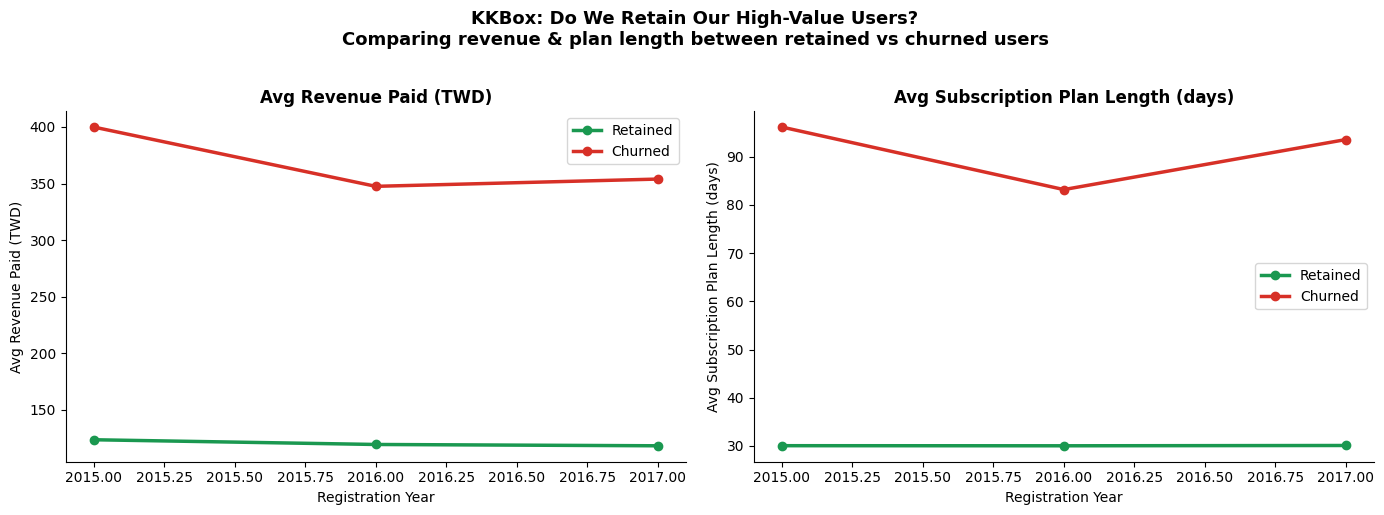

In [12]:
# ════════════════════════════════════════════════════════════
# PHASE 2B — REVENUE RETENTION vs USER RETENTION
# The interesting divergence story
# ════════════════════════════════════════════════════════════

# Revenue proxy = actual_amount_paid per user
# We compare: are we retaining HIGH value users or LOW value users?

rev_df = df[df['actual_amount_paid'].notna()].copy()
rev_df['cohort_year'] = rev_df['registration_init_time'].dt.year

# Average revenue per user by churn status and cohort year
rev_analysis = rev_df.groupby(['cohort_year', 'is_churn']).agg(
    avg_revenue    = ('actual_amount_paid', 'mean'),
    avg_plan_days  = ('payment_plan_days', 'mean'),
    user_count     = ('msno', 'count')
).reset_index()

rev_analysis['status'] = rev_analysis['is_churn'].map(
    {0: 'Retained', 1: 'Churned'}
)

# Filter to meaningful years
rev_analysis = rev_analysis[
    rev_analysis['cohort_year'].between(2015, 2017)
]

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in zip(
    axes,
    ['avg_revenue', 'avg_plan_days'],
    ['Avg Revenue Paid (TWD)', 'Avg Subscription Plan Length (days)']
):
    for status, color in [('Retained', '#1a9850'), ('Churned', '#d73027')]:
        subset = rev_analysis[rev_analysis['status'] == status]
        ax.plot(subset['cohort_year'], subset[metric],
                marker='o', label=status, color=color, linewidth=2.5)

    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Registration Year')
    ax.set_ylabel(label)
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('KKBox: Do We Retain Our High-Value Users?\n'
             'Comparing revenue & plan length between retained vs churned users',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('revenue_vs_user_retention.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 3 — What Actually Drives Churn?

We compare behavioural signals between churned and retained users. 
The key question: is churn an engagement problem (users stop listening) 
or a payments problem (users don't renew regardless of engagement)?

This distinction completely changes what interventions will work.

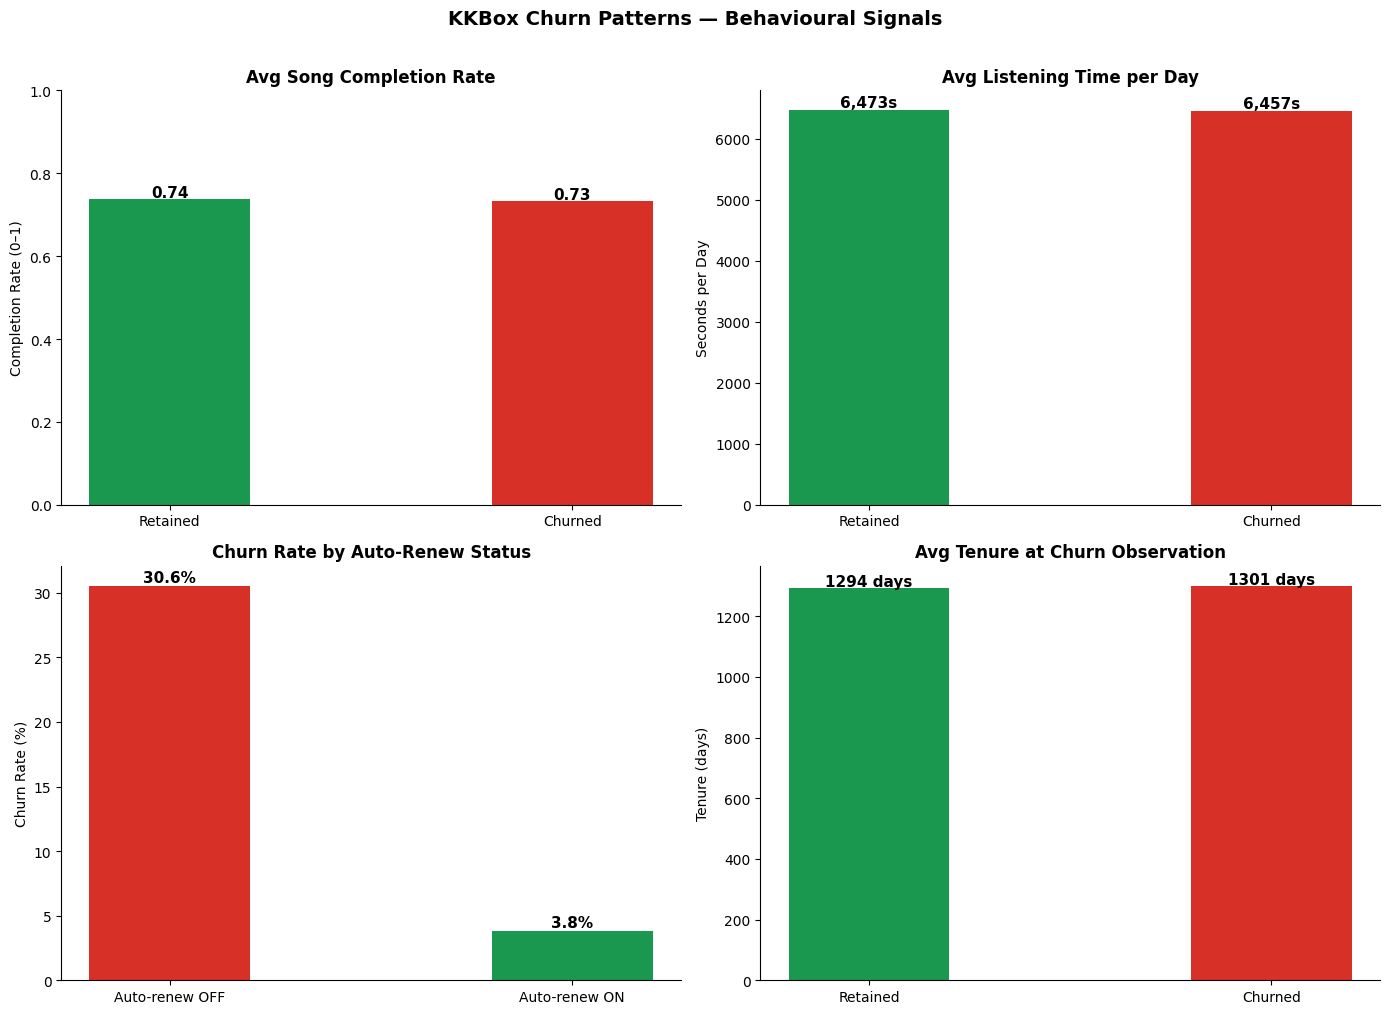

In [13]:
# ════════════════════════════════════════════════════════════
# PHASE 3 — CHURN PATTERN ANALYSIS (clean version)
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('KKBox Churn Patterns — Behavioural Signals',
             fontsize=14, fontweight='bold', y=1.01)

colors = ['#1a9850', '#d73027']
labels = ['Retained', 'Churned']

# ── 1. Avg completion rate by churn status ──
ax1 = axes[0, 0]
avg_completion = df.groupby('is_churn')['completion_rate'].mean()
bars = ax1.bar(labels, avg_completion.values, color=colors, 
               width=0.4, edgecolor='none')
for bar, val in zip(bars, avg_completion.values):
    ax1.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.005,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Avg Song Completion Rate', fontweight='bold')
ax1.set_ylabel('Completion Rate (0–1)')
ax1.set_ylim(0, 1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── 2. Avg listening time by churn status ──
ax2 = axes[0, 1]
avg_secs = df.groupby('is_churn')['avg_secs_per_day'].mean()
bars = ax2.bar(labels, avg_secs.values, color=colors,
               width=0.4, edgecolor='none')
for bar, val in zip(bars, avg_secs.values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{val:,.0f}s', ha='center', fontsize=11, fontweight='bold')
ax2.set_title('Avg Listening Time per Day', fontweight='bold')
ax2.set_ylabel('Seconds per Day')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# ── 3. Churn rate by auto-renew ──
ax3 = axes[1, 0]
auto_churn = df.groupby('is_auto_renew')['is_churn'].mean() * 100
ax3.bar(['Auto-renew OFF', 'Auto-renew ON'], 
        auto_churn.values,
        color=['#d73027', '#1a9850'],
        width=0.4, edgecolor='none')
for i, val in enumerate(auto_churn.values):
    ax3.text(i, val + 0.3, f'{val:.1f}%', 
             ha='center', fontsize=11, fontweight='bold')
ax3.set_title('Churn Rate by Auto-Renew Status', fontweight='bold')
ax3.set_ylabel('Churn Rate (%)')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# ── 4. Avg tenure by churn status ──
ax4 = axes[1, 1]
avg_tenure = df.groupby('is_churn')['tenure_days'].mean()
bars = ax4.bar(labels, avg_tenure.values, color=colors,
               width=0.4, edgecolor='none')
for bar, val in zip(bars, avg_tenure.values):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             f'{val:.0f} days', ha='center', fontsize=11, fontweight='bold')
ax4.set_title('Avg Tenure at Churn Observation', fontweight='bold')
ax4.set_ylabel('Tenure (days)')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('churn_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 4 — Churn Prediction Model

We train a classifier to score each user's churn probability. 
Before going to XGBoost, we establish a Logistic Regression baseline 
to confirm the added complexity is justified.

Features used: payment behaviour, subscription structure, 
engagement metrics, and tenure.

Class imbalance: ~9% churn rate. Handled via `scale_pos_weight` in XGBoost 
and `class_weight='balanced'` in Logistic Regression.

In [14]:
# ════════════════════════════════════════════════════════════
# PHASE 4 — CHURN PREDICTION MODEL
# XGBoost + SHAP
# ════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import shap

# ── Feature selection ──
features = [
    'city', 'registered_via',
    'payment_method_id', 'payment_plan_days',
    'plan_list_price', 'actual_amount_paid',
    'is_auto_renew', 'is_cancel', 'got_discount',
    'tenure_days',
    'total_secs', 'num_unq', 'active_days',
    'completion_rate', 'avg_secs_per_day',
    # New features
    'days_until_expiry',
    'transaction_count',
    'discount_rate',
    'never_listened'
]

target = 'is_churn'

# ── Prep ──
model_df = df[features + [target]].copy()

# Fill nulls with median
for col in features:
    if model_df[col].isnull().any():
        model_df[col] = model_df[col].fillna(model_df[col].median())

X = model_df[features]
y = model_df[target]

print(f"Feature matrix shape: {X.shape}")
print(f"Churn rate: {y.mean():.2%}")
print(f"\nNull check: {X.isnull().sum().sum()} nulls remaining")

# ── Train/test split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")

Feature matrix shape: (970960, 19)
Churn rate: 8.99%

Null check: 0 nulls remaining

Train size: 776,768
Test size:  194,192


In [15]:
# ════════════════════════════════════════════════════════════
# BASELINE MODEL — Logistic Regression
# Establish baseline before XGBoost
# If LR performs similarly, the simpler model wins
# ════════════════════════════════════════════════════════════

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        n_jobs=-1
    ))
])

print("Training Logistic Regression baseline...")
lr_pipeline.fit(X_train, y_train)

lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)

print(f"\nLogistic Regression AUC: {lr_auc:.4f}")
print("XGBoost trains next — needs to beat this to justify complexity.")

Training Logistic Regression baseline...

Logistic Regression AUC: 0.9028
XGBoost trains next — needs to beat this to justify complexity.


In [16]:
# ── Train XGBoost ──
# scale_pos_weight handles class imbalance (91% retained vs 9% churned)
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio: {scale:.1f} — passing to XGBoost")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

print("\nTraining... (takes ~2 mins)")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# ── Evaluate ──
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'='*40}")
print(f"ROC-AUC Score: {auc:.4f}")
print(f"{'='*40}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Retained', 'Churned']))

Class imbalance ratio: 10.1 — passing to XGBoost

Training... (takes ~2 mins)
[0]	validation_0-auc:0.96727
[50]	validation_0-auc:0.98007
[100]	validation_0-auc:0.98513
[150]	validation_0-auc:0.98666
[200]	validation_0-auc:0.98719
[250]	validation_0-auc:0.98748
[299]	validation_0-auc:0.98756

ROC-AUC Score: 0.9876

Classification Report:
              precision    recall  f1-score   support

    Retained       0.99      0.94      0.96    176726
     Churned       0.59      0.95      0.73     17466

    accuracy                           0.94    194192
   macro avg       0.79      0.94      0.85    194192
weighted avg       0.96      0.94      0.94    194192



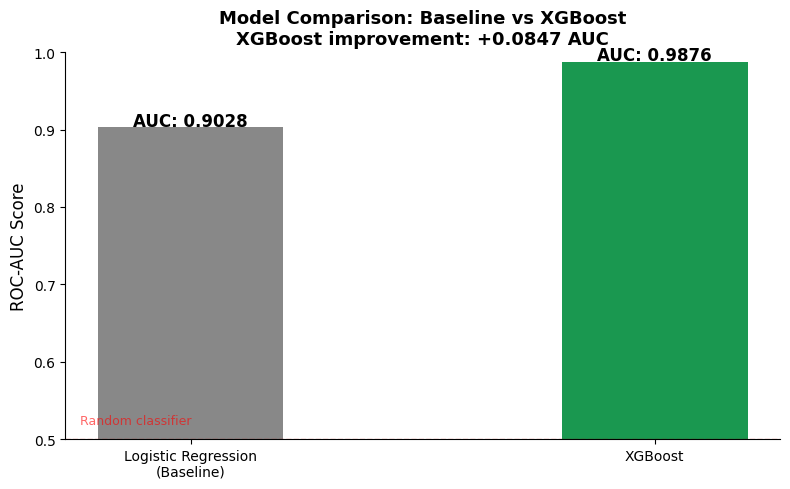


Summary:
  Logistic Regression AUC : 0.9028
  XGBoost AUC             : 0.9876
  Improvement             : +0.0847

Conclusion: XGBoost captures non-linear subscription behaviour patterns that linear models miss, justifying the added complexity.


In [17]:
# ════════════════════════════════════════════════════════════
# MODEL COMPARISON — Baseline vs XGBoost
# ════════════════════════════════════════════════════════════

xgb_auc = auc  # already computed above

fig, ax = plt.subplots(figsize=(8, 5))

models     = ['Logistic Regression\n(Baseline)', 'XGBoost']
aucs       = [lr_auc, xgb_auc]
bar_colors = ['#888888', '#1a9850']

bars = ax.bar(models, aucs, color=bar_colors, width=0.4, edgecolor='none')
for bar, val in zip(bars, aucs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'AUC: {val:.4f}',
        ha='center', fontsize=12, fontweight='bold'
    )

ax.set_ylim(0.5, 1.0)
ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_title(
    f'Model Comparison: Baseline vs XGBoost\n'
    f'XGBoost improvement: +{xgb_auc - lr_auc:.4f} AUC',
    fontsize=13, fontweight='bold'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, linewidth=1)
ax.text(0.02, 0.52, 'Random classifier', fontsize=9,
        color='red', alpha=0.6, transform=ax.get_yaxis_transform())

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSummary:")
print(f"  Logistic Regression AUC : {lr_auc:.4f}")
print(f"  XGBoost AUC             : {xgb_auc:.4f}")
print(f"  Improvement             : +{xgb_auc - lr_auc:.4f}")
print(f"\nConclusion: XGBoost captures non-linear subscription behaviour "
      f"patterns that linear models miss, justifying the added complexity.")

## Phase 5 — Model Explainability (SHAP)

SHAP (SHapley Additive exPlanations) tells us not just WHICH features
matter, but HOW they push predictions up or down for each individual user.

The beeswarm plot shows:
- Each dot = one user
- Red = high feature value, Blue = low
- Position on x-axis = impact on churn prediction

Calculating SHAP values... (takes ~2 mins)


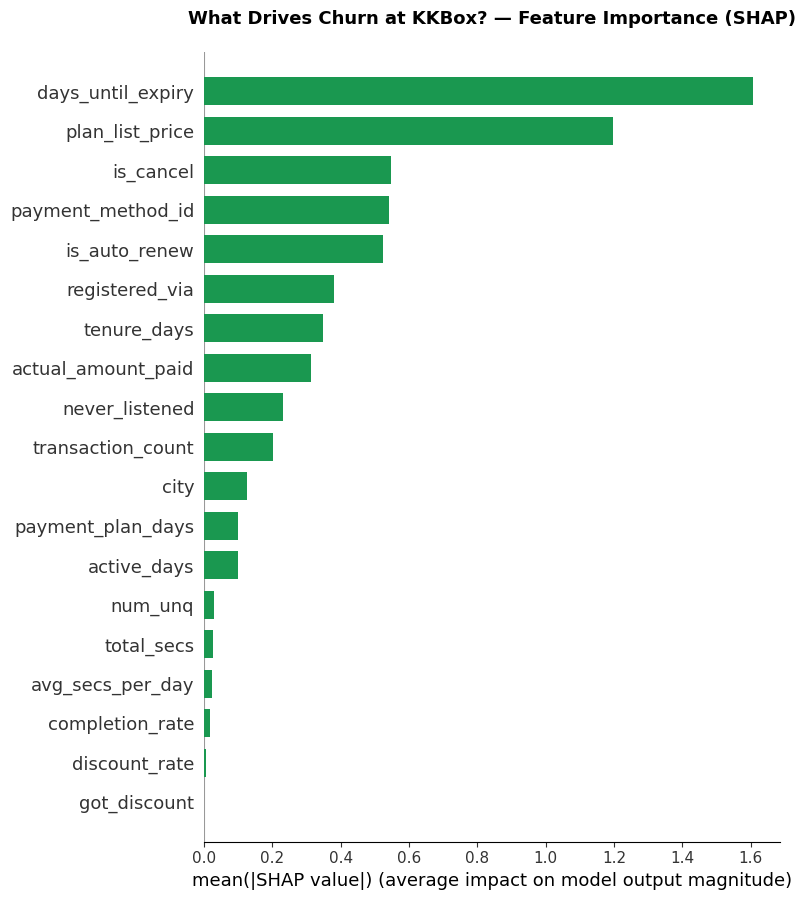

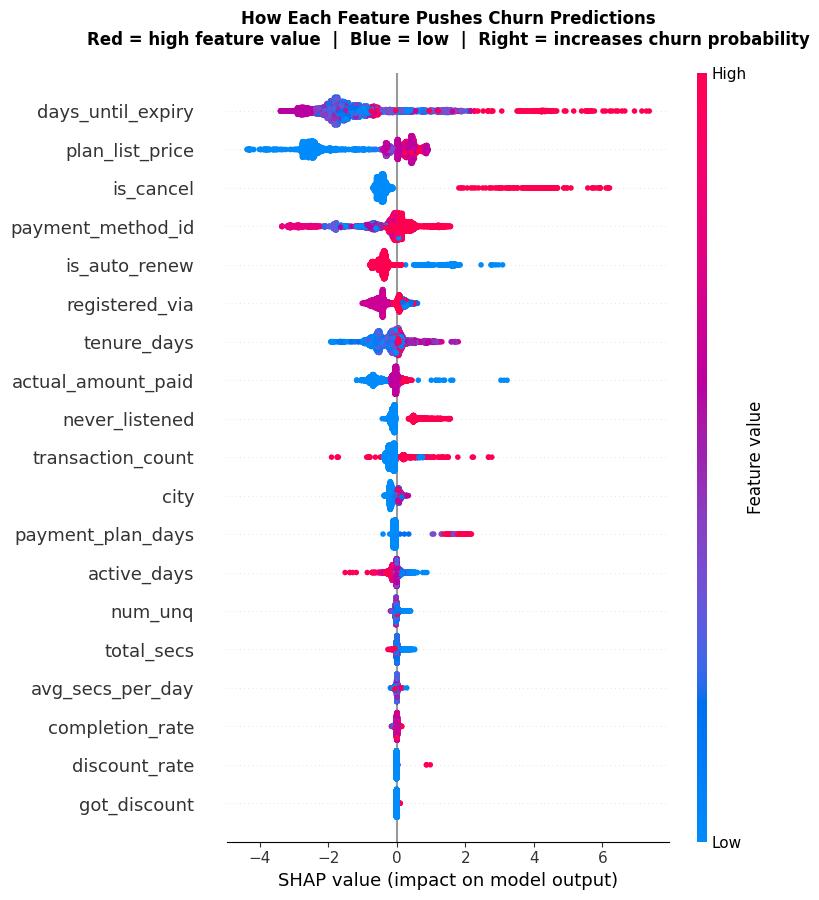

<Figure size 900x600 with 0 Axes>

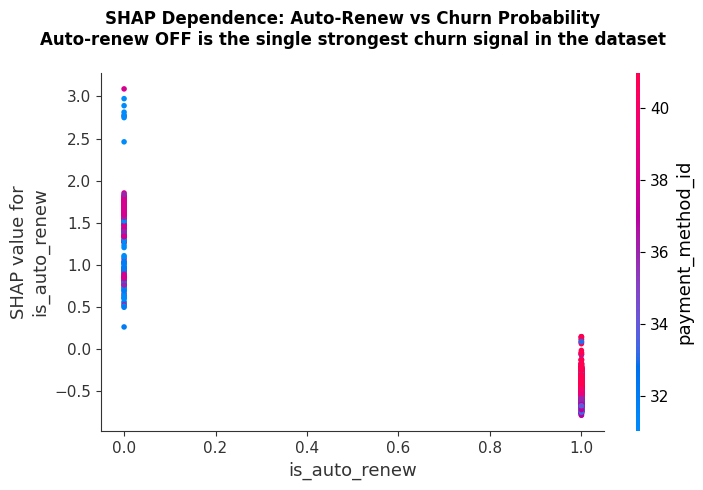

SHAP plots saved: shap_importance.png, shap_beeswarm.png, shap_dependence_autorenew.png


In [18]:
# ════════════════════════════════════════════════════════════
# SHAP EXPLAINABILITY
# Plot 1: Bar chart  — feature importance ranking
# Plot 2: Beeswarm  — direction and magnitude per user
# Plot 3: Dependence — auto-renew deep dive
# ════════════════════════════════════════════════════════════

print("Calculating SHAP values... (takes ~2 mins)")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test[:5000])

# ── Plot 1: Bar chart ──
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test[:5000],
    feature_names=features,
    plot_type='bar',
    show=False,
    color='#1a9850'
)
plt.title('What Drives Churn at KKBox? — Feature Importance (SHAP)',
          fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 2: Beeswarm ──
plt.figure(figsize=(11, 8))
shap.summary_plot(
    shap_values,
    X_test[:5000],
    feature_names=features,
    plot_type='dot',
    show=False
)
plt.title(
    'How Each Feature Pushes Churn Predictions\n'
    'Red = high feature value  |  Blue = low  |  '
    'Right = increases churn probability',
    fontsize=12, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot 3: Dependence plot — auto-renew ──
auto_renew_idx = list(features).index('is_auto_renew')

plt.figure(figsize=(9, 6))
shap.dependence_plot(
    auto_renew_idx,
    shap_values,
    X_test[:5000],
    feature_names=features,
    show=False
)
plt.title(
    'SHAP Dependence: Auto-Renew vs Churn Probability\n'
    'Auto-renew OFF is the single strongest churn signal in the dataset',
    fontsize=12, fontweight='bold', pad=20
)
plt.tight_layout()
plt.savefig('shap_dependence_autorenew.png', dpi=150, bbox_inches='tight')
plt.show()

print("SHAP plots saved: shap_importance.png, shap_beeswarm.png, shap_dependence_autorenew.png")

## Phase 6 — Risk Scoring & Business Prioritisation

We bucket every user into three risk tiers based on their churn probability.
This converts a model output into an actionable retention brief:
- Who do we contact first?
- How much revenue is at stake per tier?
- What intervention makes sense at each tier?

Risk Tier Summary:
             user_count  avg_churn_prob  actual_churn_rate  avg_plan_price  \
risk_tier                                                                    
High Risk         19869            0.95               0.78          288.30   
Low Risk         161602            0.04               0.00          126.67   
Medium Risk       12721            0.53               0.11          160.20   

             avg_tenure  revenue_at_risk  
risk_tier                                 
High Risk       1272.62       5436168.00  
Low Risk        1278.08        716449.00  
Medium Risk     1108.46       1080109.00  


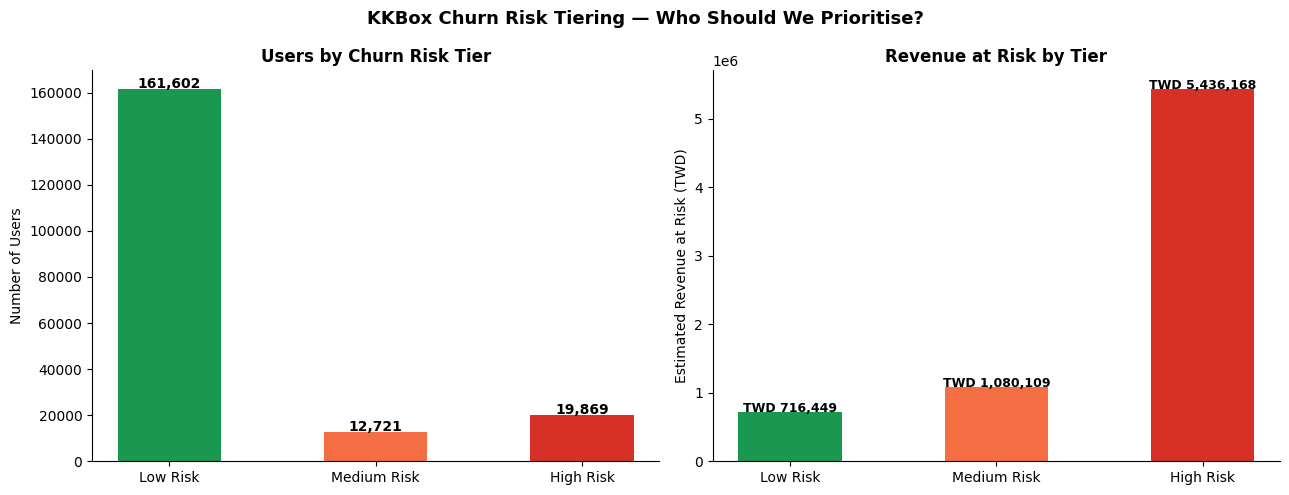

In [19]:
# ── Risk Score Bucketing ──
# Assign each user a churn risk tier

risk_df = X_test.copy()
risk_df['churn_probability'] = y_pred_proba
risk_df['actual_churn'] = y_test.values

# Bucket into risk tiers
def assign_risk(prob):
    if prob >= 0.7:
        return 'High Risk'
    elif prob >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

risk_df['risk_tier'] = risk_df['churn_probability'].apply(assign_risk)

# Summary stats per tier
risk_summary = risk_df.groupby('risk_tier').agg(
    user_count        = ('churn_probability', 'count'),
    avg_churn_prob    = ('churn_probability', 'mean'),
    actual_churn_rate = ('actual_churn', 'mean'),
    avg_plan_price    = ('plan_list_price', 'mean'),
    avg_tenure        = ('tenure_days', 'mean')
).round(3)

# Add revenue at risk estimate
risk_summary['revenue_at_risk'] = (
    risk_summary['user_count'] * 
    risk_summary['avg_churn_prob'] * 
    risk_summary['avg_plan_price']
).round(0)

print("Risk Tier Summary:")
print(risk_summary)

# ── Plot risk distribution ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1 — user count per tier
tier_order  = ['Low Risk', 'Medium Risk', 'High Risk']
tier_colors = ['#1a9850',  '#f46d43',     '#d73027']
counts = [risk_summary.loc[t, 'user_count'] 
          for t in tier_order if t in risk_summary.index]
actual_tiers = [t for t in tier_order if t in risk_summary.index]
actual_colors = [tier_colors[tier_order.index(t)] for t in actual_tiers]

bars = axes[0].bar(actual_tiers, counts, 
                   color=actual_colors, edgecolor='none', width=0.5)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Users by Churn Risk Tier', fontweight='bold')
axes[0].set_ylabel('Number of Users')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Chart 2 — revenue at risk per tier
rev_at_risk = [risk_summary.loc[t, 'revenue_at_risk'] 
               for t in tier_order if t in risk_summary.index]
bars2 = axes[1].bar(actual_tiers, rev_at_risk,
                    color=actual_colors, edgecolor='none', width=0.5)
for bar, val in zip(bars2, rev_at_risk):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1000,
                 f'TWD {val:,.0f}', ha='center', 
                 fontsize=9, fontweight='bold')
axes[1].set_title('Revenue at Risk by Tier', fontweight='bold')
axes[1].set_ylabel('Estimated Revenue at Risk (TWD)')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('KKBox Churn Risk Tiering — Who Should We Prioritise?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('risk_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 7 — Cross-Validation & Model Validation

We validate that AUC 0.9876 is stable and not a result of a lucky
train/test split. 5-fold stratified cross-validation re-trains the
model on different data splits and confirms it generalises.

Running 5-fold cross-validation... (takes ~5 mins)

5-Fold Cross-Validation Results:
  Fold scores : ['0.9873', '0.9875', '0.9873', '0.9871', '0.9880']
  Mean AUC    : 0.9875
  Std Dev     : 0.0003  (lower = more stable)
  Hold-out AUC: 0.9876

Conclusion: Model is stable and generalises well.


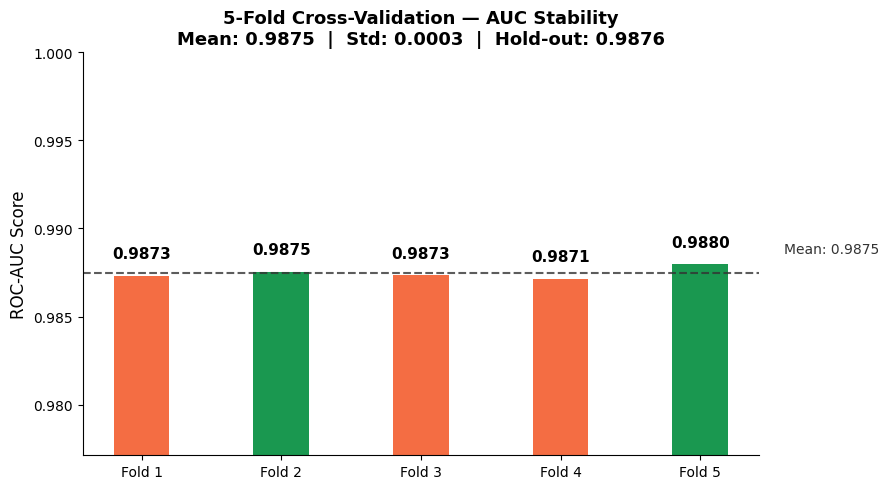

In [21]:
# ════════════════════════════════════════════════════════════
# CROSS-VALIDATION — Validate AUC is real, not a fluke
# 5-fold stratified CV confirms the model generalises
# ════════════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedKFold, cross_val_score

print("Running 5-fold cross-validation... (takes ~5 mins)")

cv_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    cv_model, X, y,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"\n5-Fold Cross-Validation Results:")
print(f"  Fold scores : {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean AUC    : {cv_scores.mean():.4f}")
print(f"  Std Dev     : {cv_scores.std():.4f}  (lower = more stable)")
print(f"  Hold-out AUC: {xgb_auc:.4f}")
print(f"\nConclusion: {'Model is stable and generalises well.' if cv_scores.std() < 0.01 else 'Some variance across folds.'}")

# ── Visualise CV stability ──
fig, ax = plt.subplots(figsize=(9, 5))

fold_labels  = [f'Fold {i+1}' for i in range(5)]
bar_colors   = ['#1a9850' if s >= cv_scores.mean() else '#f46d43'
                for s in cv_scores]

bars = ax.bar(fold_labels, cv_scores,
              color=bar_colors, width=0.4, edgecolor='none')

for bar, val in zip(bars, cv_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{val:.4f}',
        ha='center', fontsize=11, fontweight='bold'
    )

ax.axhline(y=cv_scores.mean(), color='#333333',
           linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(4.6, cv_scores.mean() + 0.001,
        f'Mean: {cv_scores.mean():.4f}',
        fontsize=10, color='#333333', va='bottom')

ax.set_ylim(cv_scores.min() - 0.01, 1.0)
ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_title(
    f'5-Fold Cross-Validation — AUC Stability\n'
    f'Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}  |  '
    f'Hold-out: {xgb_auc:.4f}',
    fontsize=13, fontweight='bold'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 8 — Threshold Optimisation

The default 0.5 classification threshold isn't always optimal.
For churn, a false negative (missing a churner) costs more than
a false positive (flagging someone who wasn't leaving).

We find the threshold that maximises F1 score across both classes.

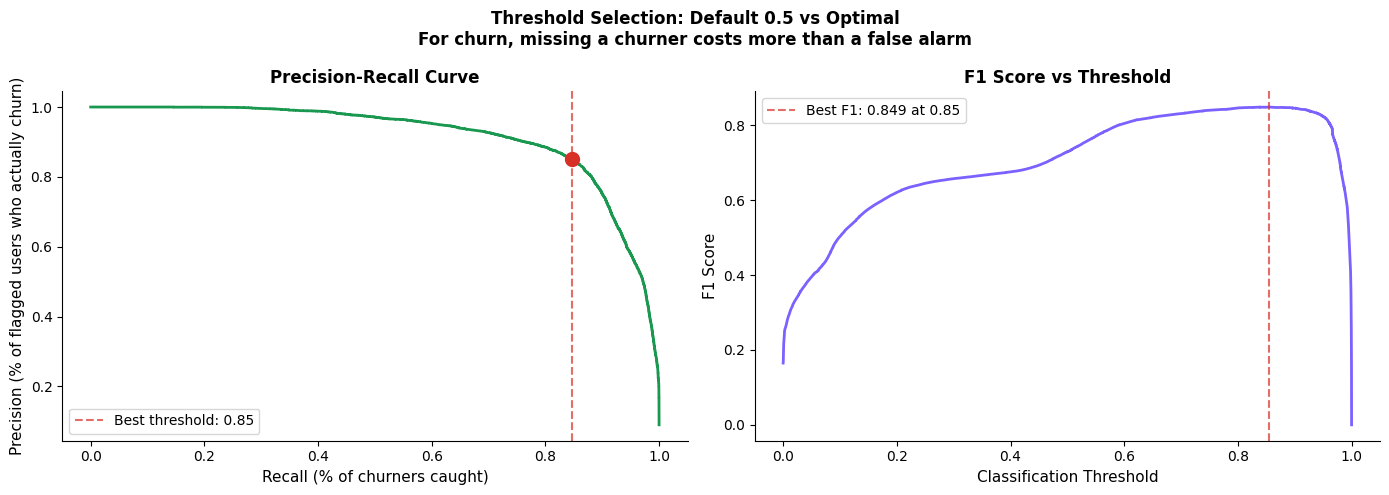

Default threshold (0.5):
  F1: 0.7290

Optimal threshold (0.85):
  F1: 0.8486

Classification Report at optimal threshold:
              precision    recall  f1-score   support

    Retained       0.98      0.99      0.99    176726
     Churned       0.85      0.85      0.85     17466

    accuracy                           0.97    194192
   macro avg       0.92      0.92      0.92    194192
weighted avg       0.97      0.97      0.97    194192



In [22]:
# ════════════════════════════════════════════════════════════
# THRESHOLD ANALYSIS
# Default 0.5 isn't always optimal for churn problems
# Missing a churner costs more than a false alarm
# ════════════════════════════════════════════════════════════

from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

f1_scores    = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx     = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Precision-Recall curve ──
axes[0].plot(recalls, precisions, color='#1a9850', linewidth=2)
axes[0].axvline(x=recalls[best_idx], color='#d73027',
                linestyle='--', alpha=0.7,
                label=f'Best threshold: {best_threshold:.2f}')
axes[0].scatter(recalls[best_idx], precisions[best_idx],
                color='#d73027', s=100, zorder=5)
axes[0].set_xlabel('Recall (% of churners caught)', fontsize=11)
axes[0].set_ylabel('Precision (% of flagged users who actually churn)', fontsize=11)
axes[0].set_title('Precision-Recall Curve', fontweight='bold')
axes[0].legend()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Plot 2: F1 score across thresholds ──
axes[1].plot(thresholds, f1_scores[:-1], color='#7B61FF', linewidth=2)
axes[1].axvline(x=best_threshold, color='#d73027',
                linestyle='--', alpha=0.7,
                label=f'Best F1: {best_f1:.3f} at {best_threshold:.2f}')
axes[1].set_xlabel('Classification Threshold', fontsize=11)
axes[1].set_ylabel('F1 Score', fontsize=11)
axes[1].set_title('F1 Score vs Threshold', fontweight='bold')
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle(
    'Threshold Selection: Default 0.5 vs Optimal\n'
    'For churn, missing a churner costs more than a false alarm',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Default threshold (0.5):")
y_default = (y_pred_proba >= 0.5).astype(int)
print(f"  F1: {f1_score(y_test, y_default):.4f}")
print(f"\nOptimal threshold ({best_threshold:.2f}):")
y_optimal = (y_pred_proba >= best_threshold).astype(int)
print(f"  F1: {f1_score(y_test, y_optimal):.4f}")
print(f"\nClassification Report at optimal threshold:")
print(classification_report(y_test, y_optimal,
      target_names=['Retained', 'Churned']))

## Phase 9 — Retention ROI

We convert model outputs into a business case.
If we act on high-risk users with a targeted incentive,
does the revenue saved justify the cost of the campaign?

In [25]:
# ════════════════════════════════════════════════════════════
# ROI CALCULATION — Corrected
# ════════════════════════════════════════════════════════════

HIGH_RISK_MASK     = risk_df['risk_tier'] == 'High Risk'
high_risk_users    = risk_df[HIGH_RISK_MASK]
n_high_risk        = len(high_risk_users)

avg_plan_price_hr  = high_risk_users['plan_list_price'].mean()
avg_churn_prob_hr  = high_risk_users['churn_probability'].mean()

# Revenue at risk = how much revenue we lose if we do nothing
revenue_at_risk    = n_high_risk * avg_churn_prob_hr * avg_plan_price_hr

# Cost of intervention = 10% discount offered to ALL high-risk users
discount_pct       = 0.10
cost_of_discount   = n_high_risk * avg_plan_price_hr * discount_pct

# Of the high-risk users, avg_churn_prob_hr % would churn without action
# We assume 30% of those churners convert to auto-renew when incentivised
# Each converted user = full plan price saved (not just the marginal rate)
expected_churners  = n_high_risk * avg_churn_prob_hr
assumed_conversion = 0.30
users_saved        = expected_churners * assumed_conversion

# Revenue saved = users saved × full plan price (we keep them as subscribers)
revenue_saved      = users_saved * avg_plan_price_hr
roi_ratio          = revenue_saved / cost_of_discount

print("=" * 55)
print("RETENTION INTERVENTION ROI — Auto-Renew Incentive")
print("=" * 55)
print(f"\nHigh-risk users identified   : {n_high_risk:,}")
print(f"Avg plan price               : TWD {avg_plan_price_hr:,.0f}")
print(f"Expected churners (no action): {expected_churners:,.0f}")
print(f"Revenue at risk              : TWD {revenue_at_risk:,.0f}")
print(f"\nIntervention: 10% discount to enable auto-renew")
print(f"Cost of campaign             : TWD {cost_of_discount:,.0f}")
print(f"Assumed conversion rate      : {assumed_conversion:.0%} of expected churners")
print(f"Est. users saved from churn  : {users_saved:,.0f}")
print(f"Est. revenue saved           : TWD {revenue_saved:,.0f}")
print(f"\nROI ratio                    : {roi_ratio:.1f}x")
print(f"\nConclusion: Targeting {n_high_risk:,} high-risk users with a "
      f"10% auto-renew incentive costs TWD {cost_of_discount:,.0f} "
      f"and protects an estimated TWD {revenue_saved:,.0f} in revenue "
      f"— a {roi_ratio:.1f}x return on retention spend.")

RETENTION INTERVENTION ROI — Auto-Renew Incentive

High-risk users identified   : 19,869
Avg plan price               : TWD 288
Expected churners (no action): 18,865
Revenue at risk              : TWD 5,438,813

Intervention: 10% discount to enable auto-renew
Cost of campaign             : TWD 572,832
Assumed conversion rate      : 30% of expected churners
Est. users saved from churn  : 5,659
Est. revenue saved           : TWD 1,631,644

ROI ratio                    : 2.8x

Conclusion: Targeting 19,869 high-risk users with a 10% auto-renew incentive costs TWD 572,832 and protects an estimated TWD 1,631,644 in revenue — a 2.8x return on retention spend.


## Export — Saving Outputs for Dashboard

We export the database, model, and all charts to feed the
live Streamlit dashboard. The SQLite database contains all
user-level data, cohort tables, risk scores, and ROI summary.

In [27]:
# ════════════════════════════════════════════════════════════
# EXPORT — Save everything the Streamlit app needs
# Run this last, after all analysis is complete
# ════════════════════════════════════════════════════════════

import sqlite3, pickle, shutil
from pathlib import Path

EXPORT_DIR = Path('/kaggle/working/export/')
EXPORT_DIR.mkdir(exist_ok=True)

# ── 1. SQLite database ──
DB_PATH = EXPORT_DIR / 'kkbox.db'
conn    = sqlite3.connect(DB_PATH)

# Main users table
users_export = df[[
    'msno', 'is_churn', 'is_auto_renew', 'is_cancel',
    'payment_plan_days', 'plan_list_price', 'actual_amount_paid',
    'registered_via', 'city', 'tenure_days',
    'completion_rate', 'avg_secs_per_day',
    'transaction_count', 'discount_rate', 'never_listened'
]].copy()
users_export.to_sql('users', conn, if_exists='replace', index=False)

# Cohort retention table — convert Period index to string for SQLite
cohort_export = retention_table.reset_index().copy()
cohort_export['cohort'] = cohort_export['cohort'].astype(str)
cohort_export.to_sql('cohort_retention', conn, if_exists='replace', index=False)
# Risk scores table
risk_export = risk_df[[
    'churn_probability', 'actual_churn',
    'risk_tier', 'plan_list_price'
]].copy()
risk_export.to_sql('risk_scores', conn, if_exists='replace', index=False)

# ROI summary table
roi_data = pd.DataFrame([{
    'n_high_risk'        : int(n_high_risk),
    'revenue_at_risk'    : round(revenue_at_risk, 0),
    'cost_of_campaign'   : round(cost_of_discount, 0),
    'revenue_saved'      : round(revenue_saved, 0),
    'roi_ratio'          : round(roi_ratio, 1),
    'avg_plan_price'     : round(avg_plan_price_hr, 0),
    'assumed_conversion' : assumed_conversion,
}])
roi_data.to_sql('roi_summary', conn, if_exists='replace', index=False)

conn.close()
print(f"Database saved: {DB_PATH}")
print(f"  Tables: users, cohort_retention, risk_scores, roi_summary")

# ── 2. Model + metadata ──
model_data = {
    'model'           : model,
    'features'        : features,
    'best_threshold'  : best_threshold,
    'lr_auc'          : lr_auc,
    'xgb_auc'         : xgb_auc,
    'cv_mean'         : cv_scores.mean(),
    'cv_std'          : cv_scores.std(),
}
with open(EXPORT_DIR / 'model.pkl', 'wb') as f:
    pickle.dump(model_data, f)
print(f"\nModel saved: {EXPORT_DIR / 'model.pkl'}")

# ── 3. Copy all PNGs ──
png_files = [
    'cohort_retention.png',
    'shap_importance.png',
    'shap_beeswarm.png',
    'shap_dependence_autorenew.png',
    'model_comparison.png',
    'cross_validation.png',
    'threshold_analysis.png',
    'risk_tiers.png',
]

print(f"\nCopying PNGs:")
for png in png_files:
    src = Path('/kaggle/working/') / png
    if src.exists():
        shutil.copy(src, EXPORT_DIR / png)
        print(f"  OK: {png}")
    else:
        print(f"  MISSING: {png} — check it was saved earlier")

# ── 4. Final summary ──
print(f"\n{'='*45}")
print(f"EXPORT COMPLETE")
print(f"{'='*45}")
print(f"Location: {EXPORT_DIR}")
print(f"Contents:")
for f in sorted(EXPORT_DIR.iterdir()):
    size_mb = f.stat().st_size / (1024*1024)
    print(f"  {f.name}: {size_mb:.1f} MB")

Database saved: /kaggle/working/export/kkbox.db
  Tables: users, cohort_retention, risk_scores, roi_summary

Model saved: /kaggle/working/export/model.pkl

Copying PNGs:
  OK: cohort_retention.png
  OK: shap_importance.png
  OK: shap_beeswarm.png
  OK: shap_dependence_autorenew.png
  OK: model_comparison.png
  OK: cross_validation.png
  OK: threshold_analysis.png
  OK: risk_tiers.png

EXPORT COMPLETE
Location: /kaggle/working/export
Contents:
  cohort_retention.png: 0.2 MB
  cross_validation.png: 0.1 MB
  kkbox.db: 85.7 MB
  model.pkl: 1.2 MB
  model_comparison.png: 0.1 MB
  risk_tiers.png: 0.1 MB
  shap_beeswarm.png: 0.2 MB
  shap_dependence_autorenew.png: 0.1 MB
  shap_importance.png: 0.1 MB
  threshold_analysis.png: 0.1 MB
